# 08 - Real-World Eye Prediction | Eye Disease Detection

Single-image inference using the saved EfficientNetV2-B0 checkpoint.

**This notebook is independent.** It does not require any previous notebook to be running. It only needs:

- `model/efficientnetv2_finetuned_best.keras`
- a fundus image path

**Constraints**

- Does not retrain or overwrite the model
- Uses the same preprocessing as `04_efficientnetv2_training.ipynb`
- Image size **224 x 224**, pixels remain **0-255**
- Same 5-class mapping: Class 0 ... Class 4
- Confidence is **not** disease severity and **not** the percentage of the eye affected
- Severity is shown as **Not available** (see notebook 07)

**Future web/app reuse**

The cell marked **CORE INFERENCE API** defines `predict_eye_disease(image_path)`. That function returns a JSON-serializable dict and can be copied into a Flask/FastAPI service later. Display and save cells below it are notebook-only UI.

Run from Step 1 to the end with kernel `.venv311 (3.11.9)`. To score another image, change `IMAGE_PATH` in Step 12 and re-run from that cell downward.


In [1]:
# STEP 1 - Environment setup and imports

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("TensorFlow:", tf.__version__)
print("Keras:", getattr(keras, "__version__", "unknown"))
print("GPUs:", tf.config.list_physical_devices("GPU"))


Python executable: d:\Practice Projects\Disease Detection\.venv311\Scripts\python.exe
TensorFlow: 2.21.0
Keras: 3.15.1
GPUs: []


In [2]:
# STEP 2 - Project paths
# Target project: D:/Practice Projects/Disease Detection

HARDCODED_ROOT = Path(r"D:/Practice Projects/Disease Detection")

if HARDCODED_ROOT.exists():
    PROJECT_ROOT = HARDCODED_ROOT
else:
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / "model").exists():
        PROJECT_ROOT = Path.cwd()

MODEL_DIR = PROJECT_ROOT / "model"
DATASET_DIR = PROJECT_ROOT / "dataset" / "Messidor-2+EyePac_Balanced"
REPORT_DIR = PROJECT_ROOT / "reports" / "real_world_prediction"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

FINETUNED_MODEL_PATH = MODEL_DIR / "efficientnetv2_finetuned_best.keras"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL:", FINETUNED_MODEL_PATH)
print("DATASET_DIR:", DATASET_DIR)
print("REPORT_DIR:", REPORT_DIR)

if not FINETUNED_MODEL_PATH.exists():
    matches = list(MODEL_DIR.rglob("*finetuned*best*.keras"))
    if matches:
        FINETUNED_MODEL_PATH = matches[0]
        print("Resolved model path:", FINETUNED_MODEL_PATH)
    else:
        raise FileNotFoundError(
            "Fine-tuned checkpoint not found: " + str(FINETUNED_MODEL_PATH)
        )


PROJECT_ROOT: D:\Practice Projects\Disease Detection
MODEL: D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
DATASET_DIR: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced
REPORT_DIR: D:\Practice Projects\Disease Detection\reports\real_world_prediction


In [3]:
# STEP 3 - Load the trained EfficientNetV2-B0 model (inference only)
# The checkpoint is not modified and not retrained.

final_model = keras.models.load_model(FINETUNED_MODEL_PATH)

print("Loaded model:")
print(FINETUNED_MODEL_PATH)
print("Model name:", getattr(final_model, "name", "unknown"))
print("Input shape:", final_model.input_shape)
print("Output shape:", final_model.output_shape)


Loaded model:
D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
Model name: EfficientNetV2B0_EyeDisease
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)


In [4]:
# STEP 5 - Existing 5-class mapping (same as notebooks 04 and 07)
# STEP 11 constant - medical disclaimer (printed with every result)

SEED = 42
IMG_SIZE = (224, 224)
NUM_CLASSES = 5

tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
    3: "Class 3",
    4: "Class 4",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Notebook 07 found no confirmed clinical severity labels in this project.
SEVERITY_LABELS_AVAILABLE = False
SEVERITY_DISPLAY = "Not available"

MEDICAL_DISCLAIMER = (
    "This system is an AI-based research prototype for eye disease screening. "
    "The prediction and confidence score are not a medical diagnosis and should "
    "not be interpreted as disease severity or percentage of eye damage. "
    "Please consult a qualified eye-care professional for clinical evaluation."
)

print("IMG_SIZE:", IMG_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)
print("CLASS_NAMES:", CLASS_NAMES)
print("SEVERITY:", SEVERITY_DISPLAY)
print()
print("DISCLAIMER:")
print(MEDICAL_DISCLAIMER)

if tuple(final_model.output_shape[1:]) != (NUM_CLASSES,):
    raise ValueError(
        f"Expected {NUM_CLASSES}-class output, got {final_model.output_shape}"
    )


IMG_SIZE: (224, 224)
NUM_CLASSES: 5
CLASS_NAMES: {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3', 4: 'Class 4'}
SEVERITY: Not available

DISCLAIMER:
This system is an AI-based research prototype for eye disease screening. The prediction and confidence score are not a medical diagnosis and should not be interpreted as disease severity or percentage of eye damage. Please consult a qualified eye-care professional for clinical evaluation.


In [6]:
# STEP 4 - Exact training preprocessing (from 04_efficientnetv2_training.ipynb)
#
# Training load_image():
#   tf.io.read_file -> decode_image(channels=3) -> resize bilinear 224x224
#   -> cast float32, KEEP 0-255
# EfficientNetV2 include_preprocessing=True performs its own normalization.
# Do not divide by 255.


def validate_image_path(image_path):
    path = Path(image_path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        raise ValueError(
            f"Unsupported image type '{path.suffix}'. "
            f"Allowed: {sorted(IMAGE_EXTENSIONS)}"
        )
    return path.resolve()


def preprocess_fundus_image(image_path):
    """Return a 224x224x3 float32 tensor in 0-255. Same as training load_image."""
    path = validate_image_path(image_path)
    image_bytes = tf.io.read_file(str(path))
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR,
    )
    image = tf.cast(image, tf.float32)
    return image, path


def prepare_model_input(image_path):
    """Return (1, 224, 224, 3) batch for Keras predict."""
    image, path = preprocess_fundus_image(image_path)
    pixel_min = float(tf.reduce_min(image))
    pixel_max = float(tf.reduce_max(image))
    if pixel_min < 0.0 or pixel_max > 255.0 + 1e-3:
        raise ValueError(
            f"Preprocessed pixels must stay in 0-255, got min={pixel_min}, max={pixel_max}"
        )
    batch = tf.expand_dims(image, axis=0)
    return batch, image, path


print("Preprocessing helpers ready.")
print("Resize:", IMG_SIZE, "| value range: 0-255 | channels: RGB")


Preprocessing helpers ready.
Resize: (224, 224) | value range: 0-255 | channels: RGB


## CORE INFERENCE API

`predict_eye_disease(image_path)` is the function a future Flask/FastAPI backend should call. It returns a plain dict (JSON-serializable). Notebook display code lives in later cells and is not required by the API.


In [8]:
# STEP 6 / 7 - predict_eye_disease()
# Reuse this function later in a web backend. Keep side effects out of it.


def predict_eye_disease(image_path, model=None):
    """Run one fundus image through the saved EfficientNetV2-B0 model.

    Parameters
    ----------
    image_path : str | Path
        Path to a local PNG/JPEG/etc. fundus image.
    model : keras.Model, optional
        Loaded model. Defaults to the checkpoint loaded in this notebook.

    Returns
    -------
    dict
        JSON-ready payload with class id, name, confidence, all class
        probabilities, and severity="Not available".
        Confidence is max(softmax). It is NOT disease severity and NOT
        the percentage of the eye that is affected.
    """
    if model is None:
        model = final_model

    batch, image_tensor, resolved_path = prepare_model_input(image_path)
    probabilities = model.predict(batch, verbose=0)[0]
    probabilities = np.asarray(probabilities, dtype=np.float32)

    if probabilities.shape != (NUM_CLASSES,):
        raise ValueError(
            f"Unexpected probability shape {probabilities.shape}, "
            f"expected ({NUM_CLASSES},)"
        )

    class_id = int(np.argmax(probabilities))
    confidence = float(np.max(probabilities))
    prob_map = {
        CLASS_NAMES[i]: float(probabilities[i])
        for i in range(NUM_CLASSES)
    }

    return {
        "image_path": str(resolved_path),
        "predicted_class_id": class_id,
        "predicted_class_name": CLASS_NAMES[class_id],
        "confidence": confidence,
        "probabilities": prob_map,
        "severity": SEVERITY_DISPLAY,
        "severity_labels_available": bool(SEVERITY_LABELS_AVAILABLE),
        "disclaimer": MEDICAL_DISCLAIMER,
        "image_size": list(IMG_SIZE),
        "pixel_range": "0-255",
        "model_path": str(FINETUNED_MODEL_PATH),
        "preprocessed_image": image_tensor.numpy(),
    }


def prediction_to_api_payload(result):
    """Strip the numpy image so the payload can go over HTTP/JSON."""
    payload = {
        key: value
        for key, value in result.items()
        if key != "preprocessed_image"
    }
    return payload


print("predict_eye_disease() is ready for notebook use and later API reuse.")


predict_eye_disease() is ready for notebook use and later API reuse.


In [9]:
# Display / save helpers (notebook UI only - not required by the API)


def display_input_image(image_path, preprocessed_image=None):
    path = Path(image_path)
    original = tf.io.read_file(str(path))
    original = tf.image.decode_image(original, channels=3, expand_animations=False)
    original = tf.cast(original, tf.float32).numpy()
    original = np.clip(original, 0, 255).astype(np.uint8)

    n_cols = 2 if preprocessed_image is not None else 1
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5))
    if n_cols == 1:
        axes = [axes]

    axes[0].imshow(original)
    axes[0].set_title(f"Input image\n{path.name}")
    axes[0].axis("off")

    if preprocessed_image is not None:
        prepared = np.clip(np.asarray(preprocessed_image), 0, 255).astype(np.uint8)
        axes[1].imshow(prepared)
        axes[1].set_title("Preprocessed input to model\n224 x 224, RGB 0-255")
        axes[1].axis("off")

    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return original


def display_prediction_result(result):
    lines = [
        "### Prediction result",
        f"- **Predicted Disease/Class:** {result['predicted_class_name']} "
        f"(id {result['predicted_class_id']})",
        f"- **Model Confidence:** {result['confidence']:.4f} "
        f"({result['confidence'] * 100:.2f}% of the softmax distribution)",
        f"- **Severity estimation:** {result['severity']}",
        "",
        "Confidence is the model's certainty over the 5 classes. "
        "It is **not** disease severity and **not** the percentage of the eye affected.",
        "",
        "| Class | Probability |",
        "|---|---:|",
    ]
    for name, prob in result["probabilities"].items():
        marker = " **(predicted)**" if name == result["predicted_class_name"] else ""
        lines.append(f"| {name}{marker} | {prob:.4f} |")
    lines.extend(["", "> " + result["disclaimer"]])
    display(Markdown("\n".join(lines)))


def plot_class_probabilities(result, save_path=None):
    names = list(result["probabilities"].keys())
    values = [result["probabilities"][n] for n in names]
    colors = [
        "#1f77b4" if n == result["predicted_class_name"] else "#9aa0a6"
        for n in names
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(names, values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Softmax probability")
    ax.set_title(
        "Class probabilities (model confidence, not disease severity)"
    )
    ax.set_xlabel("Class")
    for i, val in enumerate(values):
        ax.text(i, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_prediction_visualization(result, original_image, save_path):
    names = list(result["probabilities"].keys())
    values = [result["probabilities"][n] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].imshow(original_image)
    axes[0].set_title(
        f"{result['predicted_class_name']}\n"
        f"confidence {result['confidence']:.3f} | severity: {result['severity']}"
    )
    axes[0].axis("off")

    axes[1].bar(names, values)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Softmax probability")
    axes[1].set_title("Class probabilities")
    axes[1].tick_params(axis="x", rotation=20)

    fig.suptitle("Real-world eye prediction (research prototype, not a diagnosis)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


print("Display helpers ready.")


Display helpers ready.


## Interactive input

Change `IMAGE_PATH` below, then run this cell and the remaining cells to score a different image. You do not need to reload the model.


In [10]:
# STEP 12 / 13 - Set IMAGE_PATH (change this to score another image)
# Default test image is an existing file from Messidor-2+EyePac_Balanced.

IMAGE_PATH = DATASET_DIR / "0" / "20051020_43808_0100_PP.png"

print("IMAGE_PATH:", IMAGE_PATH)
print("Exists:", Path(IMAGE_PATH).exists())

if not Path(IMAGE_PATH).exists():
    fallback = next(DATASET_DIR.rglob("*.png"), None)
    if fallback is None:
        fallback = next(DATASET_DIR.rglob("*.jpeg"), None)
    if fallback is None:
        raise FileNotFoundError(
            f"Default test image missing: {IMAGE_PATH}. "
            "Set IMAGE_PATH to a valid fundus image."
        )
    IMAGE_PATH = fallback
    print("Using fallback test image:", IMAGE_PATH)


IMAGE_PATH: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png
Exists: True


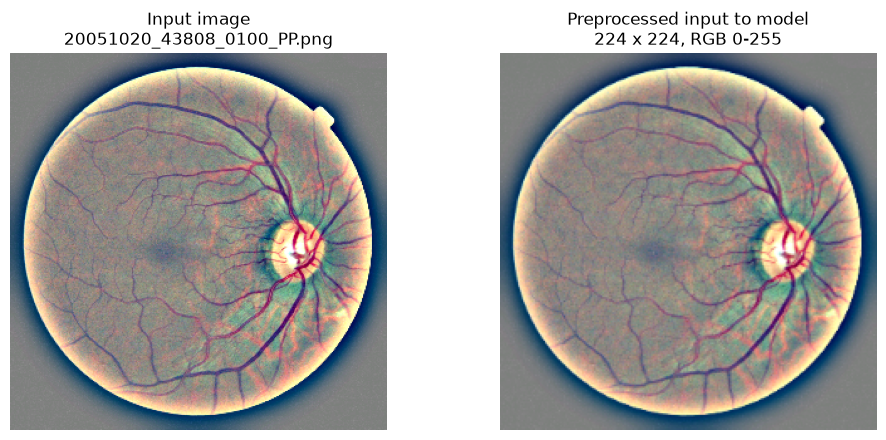

### Prediction result
- **Predicted Disease/Class:** Class 2 (id 2)
- **Model Confidence:** 0.4807 (48.07% of the softmax distribution)
- **Severity estimation:** Not available

Confidence is the model's certainty over the 5 classes. It is **not** disease severity and **not** the percentage of the eye affected.

| Class | Probability |
|---|---:|
| Class 0 | 0.2017 |
| Class 1 | 0.3151 |
| Class 2 **(predicted)** | 0.4807 |
| Class 3 | 0.0014 |
| Class 4 | 0.0010 |

> This system is an AI-based research prototype for eye disease screening. The prediction and confidence score are not a medical diagnosis and should not be interpreted as disease severity or percentage of eye damage. Please consult a qualified eye-care professional for clinical evaluation.

Predicted class: Class 2
Confidence: 0.4807
Severity: Not available
Probabilities: {'Class 0': 0.2017, 'Class 1': 0.3151, 'Class 2': 0.4807, 'Class 3': 0.0014, 'Class 4': 0.001}


In [11]:
# STEP 7-9 - Run prediction and display the input image + result

result = predict_eye_disease(IMAGE_PATH, model=final_model)

original_image = display_input_image(
    result["image_path"],
    preprocessed_image=result["preprocessed_image"],
)

display_prediction_result(result)

print("Predicted class:", result["predicted_class_name"])
print("Confidence:", round(result["confidence"], 4))
print("Severity:", result["severity"])
print("Probabilities:", {k: round(v, 4) for k, v in result["probabilities"].items()})


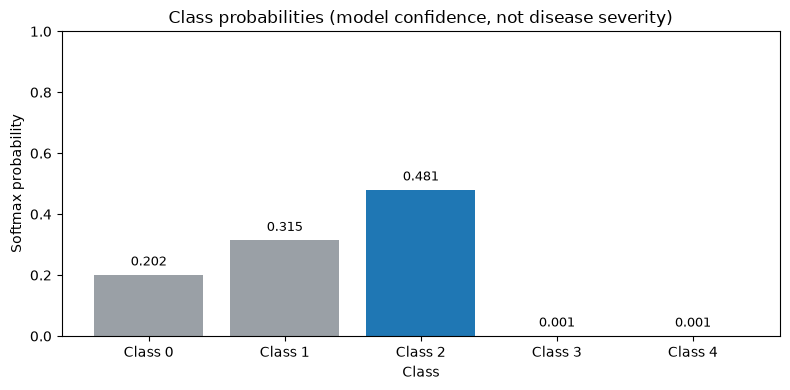

Bars show softmax P(class | image). Not a severity percentage.


In [12]:
# STEP 10 - Confidence bar chart for all 5 classes

plot_class_probabilities(result)
print("Bars show softmax P(class | image). Not a severity percentage.")


In [13]:
# STEP 11 - Medical disclaimer (printed with the saved prediction)

print("=" * 72)
print("MEDICAL DISCLAIMER")
print("=" * 72)
print(MEDICAL_DISCLAIMER)
print("=" * 72)


MEDICAL DISCLAIMER
This system is an AI-based research prototype for eye disease screening. The prediction and confidence score are not a medical diagnosis and should not be interpreted as disease severity or percentage of eye damage. Please consult a qualified eye-care professional for clinical evaluation.


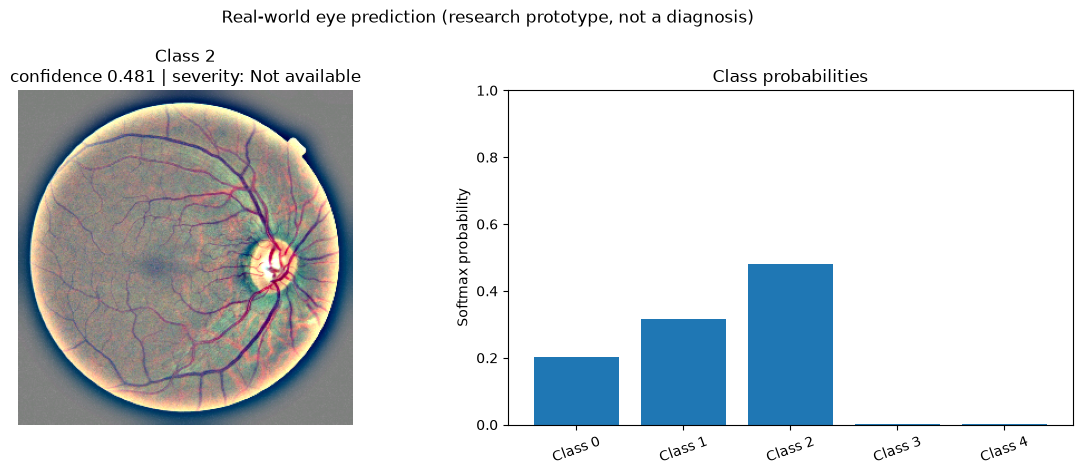

Saved:
  D:\Practice Projects\Disease Detection\reports\real_world_prediction\prediction.csv
  D:\Practice Projects\Disease Detection\reports\real_world_prediction\probabilities.csv
  D:\Practice Projects\Disease Detection\reports\real_world_prediction\prediction_visualization.png
  D:\Practice Projects\Disease Detection\reports\real_world_prediction\last_prediction.json


,image_path,predicted_class_id,predicted_class_name,confidence,severity,severity_labels_available,image_size,pixel_range,model_path
0,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.480714,Not available,False,224x224,0-255,D:\Practice Projects\Disease Detection\model\e...


,image_path,class_id,class_name,probability,is_predicted_class
0,D:\Practice Projects\Disease Detection\dataset...,0,Class 0,0.201719,False
1,D:\Practice Projects\Disease Detection\dataset...,1,Class 1,0.315136,False
2,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.480714,True
3,D:\Practice Projects\Disease Detection\dataset...,3,Class 3,0.001436,False
4,D:\Practice Projects\Disease Detection\dataset...,4,Class 4,0.000995,False


In [15]:
# STEP 14 / 15 - Save prediction CSV, probability CSV, and visualization PNG

prediction_csv = REPORT_DIR / "prediction.csv"
probability_csv = REPORT_DIR / "probabilities.csv"
visualization_png = REPORT_DIR / "prediction_visualization.png"

prediction_row = pd.DataFrame([{
    "image_path": result["image_path"],
    "predicted_class_id": result["predicted_class_id"],
    "predicted_class_name": result["predicted_class_name"],
    "confidence": result["confidence"],
    "severity": result["severity"],
    "severity_labels_available": result["severity_labels_available"],
    "image_size": "224x224",
    "pixel_range": result["pixel_range"],
    "model_path": result["model_path"],
}])
prediction_row.to_csv(prediction_csv, index=False)

probability_rows = pd.DataFrame([
    {
        "image_path": result["image_path"],
        "class_id": i,
        "class_name": CLASS_NAMES[i],
        "probability": result["probabilities"][CLASS_NAMES[i]],
        "is_predicted_class": CLASS_NAMES[i] == result["predicted_class_name"],
    }
    for i in range(NUM_CLASSES)
])
probability_rows.to_csv(probability_csv, index=False)

payload_json = REPORT_DIR / "last_prediction.json"
with payload_json.open("w", encoding="utf-8") as f:
    json.dump(prediction_to_api_payload(result), f, indent=2)

save_prediction_visualization(result, original_image, visualization_png)

print("Saved:")
print(" ", prediction_csv)
print(" ", probability_csv)
print(" ", visualization_png)
print(" ", payload_json)
display(prediction_row)
display(probability_rows)


## Optional batch prediction

Set `BATCH_DIR` to a folder of fundus images. `BATCH_LIMIT` caps how many files are scored in this notebook run (CPU-friendly). Set `BATCH_LIMIT = None` to predict **every** valid image in the folder.


In [16]:
# STEP 16 / 17 - Batch prediction for a folder


def iter_image_files(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    if not folder.is_dir():
        raise ValueError(f"Not a directory: {folder}")
    files = [
        p for p in sorted(folder.iterdir())
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
    return files


def predict_folder(folder, model=None, limit=None):
    files = iter_image_files(folder)
    if limit is not None:
        files = files[: int(limit)]

    rows = []
    for i, path in enumerate(files, start=1):
        item = predict_eye_disease(path, model=model)
        row = {
            "image_path": item["image_path"],
            "predicted_class_id": item["predicted_class_id"],
            "predicted_class_name": item["predicted_class_name"],
            "confidence": item["confidence"],
            "severity": item["severity"],
        }
        for class_id in range(NUM_CLASSES):
            name = CLASS_NAMES[class_id]
            row[f"prob_{name.replace(' ', '_').lower()}"] = item["probabilities"][name]
        rows.append(row)
        print(
            f"[{i}/{len(files)}] {path.name} -> "
            f"{item['predicted_class_name']} "
            f"(confidence {item['confidence']:.3f})"
        )
    return pd.DataFrame(rows)


# Change these two lines to batch-score another folder.
BATCH_DIR = DATASET_DIR / "0"
BATCH_LIMIT = 8

print("BATCH_DIR:", BATCH_DIR)
print("BATCH_LIMIT:", BATCH_LIMIT)
print("Valid images in folder:", len(iter_image_files(BATCH_DIR)))

batch_df = predict_folder(
    BATCH_DIR,
    model=final_model,
    limit=BATCH_LIMIT,
)

batch_csv = REPORT_DIR / "batch_predictions.csv"
batch_df.to_csv(batch_csv, index=False)

print()
print("Saved batch results:", batch_csv)
display(batch_df)


BATCH_DIR: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0
BATCH_LIMIT: 8
Valid images in folder: 360
[1/8] 20051020_43808_0100_PP.png -> Class 2 (confidence 0.481)
[2/8] 20051020_44261_0100_PP.png -> Class 2 (confidence 0.541)
[3/8] 20051020_44284_0100_PP.png -> Class 2 (confidence 0.659)
[4/8] 20051020_44338_0100_PP.png -> Class 2 (confidence 0.461)
[5/8] 20051020_44400_0100_PP.png -> Class 1 (confidence 0.420)
[6/8] 20051020_44431_0100_PP.png -> Class 2 (confidence 0.662)
[7/8] 20051020_44982_0100_PP.png -> Class 0 (confidence 0.525)
[8/8] 20051020_56791_0100_PP.png -> Class 2 (confidence 0.742)

Saved batch results: D:\Practice Projects\Disease Detection\reports\real_world_prediction\batch_predictions.csv


,image_path,predicted_class_id,predicted_class_name,confidence,severity,prob_class_0,prob_class_1,prob_class_2,prob_class_3,prob_class_4
0,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.480714,Not available,0.201719,0.315136,0.480714,0.001436,0.000995
1,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.541063,Not available,0.291018,0.161342,0.541063,0.004478,0.002099
2,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.658989,Not available,0.211659,0.118941,0.658989,0.005259,0.005152
3,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.460905,Not available,0.114709,0.393158,0.460905,0.014802,0.016426
4,D:\Practice Projects\Disease Detection\dataset...,1,Class 1,0.420042,Not available,0.206971,0.420042,0.365111,0.002442,0.005435
5,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.661942,Not available,0.165316,0.146461,0.661942,0.002839,0.023442
6,D:\Practice Projects\Disease Detection\dataset...,0,Class 0,0.524796,Not available,0.524796,0.150311,0.323699,0.000869,0.000326
7,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0.742049,Not available,0.218141,0.036917,0.742049,0.002089,0.000805


# Final summary

The next cell restates the last single-image result, whether severity is available, and where files were written.


In [17]:
# Final summary for the last IMAGE_PATH run

print("=" * 72)
print("REAL-WORLD PREDICTION SUMMARY")
print("=" * 72)
print("Input image:", result["image_path"])
print("Predicted class:", result["predicted_class_name"])
print("Predicted class id:", result["predicted_class_id"])
print(f"Confidence: {result['confidence']:.4f} (softmax max, not severity)")
print("Severity estimation:", result["severity"])
print("Severity labels available:", result["severity_labels_available"])
print()
print("All class probabilities:")
for name, prob in result["probabilities"].items():
    flag = " <-- predicted" if name == result["predicted_class_name"] else ""
    print(f"  {name}: {prob:.4f}{flag}")
print()
print("Output files:")
print("  ", REPORT_DIR / "prediction.csv")
print("  ", REPORT_DIR / "probabilities.csv")
print("  ", REPORT_DIR / "prediction_visualization.png")
print("  ", REPORT_DIR / "last_prediction.json")
print("  ", REPORT_DIR / "batch_predictions.csv")
print()
print("Disclaimer:")
print(MEDICAL_DISCLAIMER)
print("=" * 72)

display_prediction_result(result)


REAL-WORLD PREDICTION SUMMARY
Input image: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png
Predicted class: Class 2
Predicted class id: 2
Confidence: 0.4807 (softmax max, not severity)
Severity estimation: Not available
Severity labels available: False

All class probabilities:
  Class 0: 0.2017
  Class 1: 0.3151
  Class 2: 0.4807 <-- predicted
  Class 3: 0.0014
  Class 4: 0.0010

Output files:
   D:\Practice Projects\Disease Detection\reports\real_world_prediction\prediction.csv
   D:\Practice Projects\Disease Detection\reports\real_world_prediction\probabilities.csv
   D:\Practice Projects\Disease Detection\reports\real_world_prediction\prediction_visualization.png
   D:\Practice Projects\Disease Detection\reports\real_world_prediction\last_prediction.json
   D:\Practice Projects\Disease Detection\reports\real_world_prediction\batch_predictions.csv

Disclaimer:
This system is an AI-based research prototype for eye disease screeni

### Prediction result
- **Predicted Disease/Class:** Class 2 (id 2)
- **Model Confidence:** 0.4807 (48.07% of the softmax distribution)
- **Severity estimation:** Not available

Confidence is the model's certainty over the 5 classes. It is **not** disease severity and **not** the percentage of the eye affected.

| Class | Probability |
|---|---:|
| Class 0 | 0.2017 |
| Class 1 | 0.3151 |
| Class 2 **(predicted)** | 0.4807 |
| Class 3 | 0.0014 |
| Class 4 | 0.0010 |

> This system is an AI-based research prototype for eye disease screening. The prediction and confidence score are not a medical diagnosis and should not be interpreted as disease severity or percentage of eye damage. Please consult a qualified eye-care professional for clinical evaluation.